In [1]:
import uuid
from datetime import datetime
import json
from tqdm import tqdm
tqdm.pandas()

from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

import sys
sys.path.append('../backend/app')

from database.connection import db

from typing import Annotated, Literal, Any, List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.messages import AnyMessage, AIMessage, ToolMessage, HumanMessage, SystemMessage
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.runnables import RunnableLambda, RunnableWithFallbacks, RunnableConfig
from langchain_core.tools import tool

from langgraph.prebuilt import ToolNode
from langgraph.types import interrupt
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

from dotenv import load_dotenv
load_dotenv()

True

## Text to SQL
* 결과가 없을 때, humman in the loop
    * 언제 검사할 것인지
    * 어떻게 확인할 것인지
* user_id를 통해 user가 가져올 수 있는 정보의 범위 제한
    * 언제 검사할 것인지
    * 어떻게 확인할 것인지

In [2]:
class SqlState(TypedDict):
    origin_query: Annotated[str, "origin user query"]
    rewritten_query: Annotated[List[AIMessage], add_messages]
    user_id: Annotated[str, "User ID"]
    messages: Annotated[list[AnyMessage], add_messages]
    cancelled: bool
    error_num: int

### 1. DB 스키마 

In [3]:
schema = """
[Notice]
This is the schema of all available tables in the database.
Please proceed with your task based on the schema below.

[Schema]
{{
"tables": {{
    "pose_scores": {{
        "columns": {{
            "id": "int, primary key, auto increment",
            "session_id": "int, foreign key → pose_evaluation_sessions.id",
            "connection_index": "varchar(100), not null, example: '11-12'",
            "user_score": "decimal(10,4), not null",
            "status": "enum('achieved','warning','below_standard'), default 'achieved'"
        }}
    }},
    "sport_standard_scores": {{
        "columns": {{
            "id": "int, primary key, auto increment",
            "video_id": "int, foreign key → videos.id",
            "connection_index": "varchar(100), not null, example: '11-12'",
            "connection_name": "varchar(100), not null, example: '왼쪽엉덩이-오른쪽엉덩이'",
            "standard_score": "decimal(5,2), not null"
        }}
    }},
    "pose_evaluation_sessions": {{
        "columns": {{
            "id": "int, primary key, auto increment",
            "user_id": "int, foreign key → users.id",
            "sport_id": "int, foreign key → sports.id",
            "user_video_id": "int, foreign key → videos.id",
            "standard_video_id": "int, foreign key → videos.id",
            "created_at": "timestamp, default CURRENT_TIMESTAMP"
        }}
    }},
    "sports": {{
        "columns": {{
            "id": "int, primary key, auto increment",
            "name": "enum('인상', '용상')",
        }}
    }}
}},
"relationships": [
    {{"from": "pose_scores.session_id", "to": "pose_evaluation_sessions.id"}},
    {{"from": "pose_evaluation_sessions.sport_id", "to": "sports.id"}},
    {{"from": "sport_standard_scores.video_id", "to": "videos.id"}}
    ]
}}
"""

### 2. Text to SQL을 위한 query rewrite
- 목적: 자연어로 입력된 사용자의 질의를 DB에서 쉽게 사용할 수 있는 명확하고 일관된 질의문으로 변환하기 위한 프롬프트 설계.

- 이 프롬프트의 핵심 규칙 요약:
    1. 시간 표준화(Temporal Standardization)
        - "어제", "저번 주" 등과 같은 상대적 시간 표현을 절대적인 날짜 혹은 기간으로 명확하게 변환한다.
        - 예: "어제" → "2025-11-05" (현재 컨텍스트 날짜 기준)
    2. 동작명 표준화(Exercise Standardization)
        - 비표준적인 운동/동작명은 Exercise Map에서 매핑된 표준 한글명으로 치환한다.
        - 예: "클린 엔 저크", "clean and jerk" → "인상"
    3. 신체 부위 명확화 및 추상 그룹 해체(Body Part Standardization & Grouping)
        - "하체", "상체", "팔" 등과 같이 추상적 신체 그룹 표현이 등장하면, 해당 그룹에 포함된 Keypoint Connection Names의 구체 목록을 명시적으로 질의문에 제시한다.
        - 예: "하체" → ["왼쪽엉덩이-왼쪽무릎", "오른쪽엉덩이-오른쪽무릎", "왼쪽무릎-왼쪽발목", "오른쪽무릎-오른쪽발목"]
    4. 명확성과 독립성(Clarity)
        - 재작성된 질의는 Text-to-SQL Agent로 바로 전달되어도 될 만큼, 독립적이고 모호성이 없도록 충분한 정보를 담고 있어야 한다.

- 예시
    - 입력: "어제 영상에서 하체 부위의 점수는 몇 점이야?"
    - 최종 재작성: "2025-10-01 영상에서 '왼쪽엉덩이-왼쪽무릎', '오른쪽엉덩이-오른쪽무릎', '왼쪽무릎-왼쪽발목', '오른쪽무릎-오른쪽발목' 부위의 평균 점수를 조회."
- 프롬프트 입력 주의점
    - 신체부위와 관련해 "~~ 부위"와 "~~에서" 입력 시 차이가 발생
        - "골반에서" -> "왼쪽엉덩이-오른쪽엉덩어"
        - "골반 부위에서" -> "왼쪽엉덩이-왼쪽무릎", "오른쪽엉덩이-오른쪽무릎"

In [4]:
class QueryRewriteSQL(BaseModel):
    """ Schema for the rewritten user query to enhance downstream DB querying. """
    rewritten_query: str = Field(
        ...,
        description="A string that rewrites the natural language query into a DB-friendly format."
    )

queryRewrite_parser = PydanticOutputParser(pydantic_object=QueryRewriteSQL)

In [2]:
rewriteSql_template = """
[SYSTEM ROLE]
You are the Query Rewriter Agent. Your sole task is to rewrite the user's natural language query into a clear, unambiguous, and DB-friendly format. This rewritten query will be passed directly to the Text-to-SQL Agent. You MUST first think carefully and slowly, following all the rules provided.

[REWRITING RULES]
1. Temporal Standardization: Resolve all relative time expressions (e.g., "어제", "저번 주") into absolute date ranges or specific dates using the provided Current Datetime.
2. Exercise Standardization: Replace all non-standard exercise names with the standardized Korean names from the Exercise Map.
3. Body Part Standardization & Grouping:
    *   If the user mentions an abstract group (e.g., "종아리", "팔뚝", "몸통"), you must infer the corresponding list of Keypoint Connection Names (e.g., "왼쪽어깨-왼쪽팔꿈치") and include them in the rewritten query.
    *   The rewritten query must explicitly list the Keypoint Connection Names instead of the abstract group name.
4. Clarity: The final rewritten query must be a clear, self-contained instruction for the Text-to-SQL Agent, containing all standardized information.


[CONTEXT]
- Current Datetime: {current_datetime}
- Exercise Map: {{
    "클린 엔 저크": "인상",
    "clean and jerk": "인상",
    ...
    "인상": "인상",
    "스내치": "용상",
    "snatch": "용상",
    "snatc": "용상",
    ...
    "용상": "용상",
    }}
- Keypoint Connection Names: [
    "왼쪽어깨-오른쪽어깨", "왼쪽어깨-왼쪽팔꿈치", "왼쪽어깨-왼쪽엉덩이",
     오른쪽어깨-오른쪽팔꿈치", "오른쪽어깨-오른쪽엉덩이",
    "왼쪽팔꿈치-왼쪽손목", "오른쪽팔꿈치-오른쪽손목", 
    "왼쪽엉덩이-오른쪽엉덩이", "왼쪽엉덩이-왼쪽무릎", "오른쪽엉덩이-오른쪽무릎", 
    "왼쪽무릎-왼쪽발목", "오른쪽무릎-오른쪽발목"
    ]

[OUTPUT FORMAT]
{format}

[FEW-SHOT EXAMPLES]

Example 1 (Temporal & Exercise Standardization & Abstract Groupting - 허리)
User Query: "오늘 올린 snach 영상의 허리 관련 점수를 알려줘."
Draft (CoT):
1. Temporal: "오늘" -> {current_datetime}.
2. Exercise: "snach" -> "용상".
3. grouping: "허리" is an abstract group. Infer Keypoint Connection Names: 허리('왼쪽어깨-왼쪽엉덩이', '오른쪽어깨-오른쪽엉덩이').
4. Rewrite: {current_datetime}에 업로드된 용상 영상의 '왼쪽어깨-왼쪽엉덩이', '오른쪽어깨-오른쪽엉덩이' 부위의 점수를 조회."

Example 2 (Excercise Standardization & Abstract Groupting - 다리)
User Query: "clean&jerk 영상에서 종아리 부위 점수의 동향을 알려줘.
Draft (CoT):
1. Exercise: "clean&jerk" -> "인상"
2. Grouping: "종아리" is an abstract group. Infer Keypoint Connection Names: 팔('왼쪽무릎-왼쪽발목', '오른쪽무릎-오른쪽발목').
3. Rewrite: 인상 영상에서 '왼쪽무릎-왼쪽발목', '오른쪽무릎-오른쪽발목' 부위의 점수 동향을 조회.

[USER QUERY]
{user_query}
"""

In [6]:
llm = ChatOpenAI(
    model="gpt-4o-mini", 
    temperature=0
)

In [7]:
prompt = ChatPromptTemplate.from_messages([
    ("system", schema),
    ("system", rewriteSql_template)
])

prompt = prompt.partial(format=queryRewrite_parser.get_format_instructions())

rewrite_sql_chain = prompt | llm

In [48]:
result = rewrite_sql_chain.invoke({'user_query': '어제의 클린 엔 저크 동작 영상 결과에서 골반 점수의 동향을 알려줘.', 'current_datetime': datetime.now().strftime('%Y-%m-%d %H:%M:%S')})

queryRewrite_parser.parse(result.content).rewritten_query

"2025-11-18 23:00:43에 업로드된 인상 영상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회."

In [49]:
result = rewrite_sql_chain.invoke({'user_query': '10일 전 올린 클린 엔 저크 영상의 분석 결과에서 상체에서 가장 낮은 점수를 조회해줘.', 'current_datetime': datetime.now().strftime('%Y-%m-%d %H:%M:%S')})

queryRewrite_parser.parse(result.content).rewritten_query

"2025-11-09 23:00:45에 업로드된 인상 영상의 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치' 부위에서 가장 낮은 점수를 조회."

In [50]:
result = rewrite_sql_chain.invoke({'user_query': '그제 올린 snatch 분석 결과에서 골반에서 가장 낮은 점수를 조회해줘.', 'current_datetime': datetime.now().strftime('%Y-%m-%d %H:%M:%S')})

queryRewrite_parser.parse(result.content).rewritten_query

"2025-11-17 23:00:48에 업로드된 용상 영상의 '왼쪽엉덩이-오른쪽엉덩이' 부위에서 가장 낮은 점수를 조회."

In [13]:
result = rewrite_sql_chain.invoke({'user_query': '이번달 초 즈음 분석 결과에서 종아리에서 가장 낮은 점수를 조회해줘.', 'current_datetime': datetime.now().strftime('%Y-%m-%d %H:%M:%S')})

queryRewrite_parser.parse(result.content).rewritten_query

"2025-11-01 00:00:00부터 2025-11-19 15:06:19 사이의 분석 결과에서 '왼쪽무릎-왼쪽발목', '오른쪽무릎-오른쪽발목' 부위의 가장 낮은 점수를 조회."

In [16]:
# 문제가 되고 있음
result = rewrite_sql_chain.invoke({'user_query': '클린 엔 저크에서 골반 부위 점수의 동향을 알려줘.', 'current_datetime': datetime.now().strftime('%Y-%m-%d %H:%M:%S')})

queryRewrite_parser.parse(result.content).rewritten_query

"인상 영상에서 '왼쪽엉덩이-오른쪽엉덩이' 부위의 점수 동향을 조회."

In [8]:
def query_rewrite_sql(state: SqlState) -> dict[str, list[AIMessage]]:
    """
    This stage transforms the input message to fit the database schema before converting it to SQL.
    """
    input_query = state['origin_query'].content 

    rewritten_query = rewrite_sql_chain.invoke({"user_query": input_query, 
                                                "current_datetime": datetime.now().strftime('%Y-%m-%d')})
    rewritten_query = queryRewrite_parser.parse(rewritten_query.content).rewritten_query
    
    rewritten_message = AIMessage(content=f"{rewritten_query}")
    
    return {
        "rewritten_query": [AIMessage(content=rewritten_query)],
        "messages": [rewritten_message]  # messages에도 추가
    }

### 3. execute_query
* ToolNode(tools): 도구를 실행하는 노드 생성
* .with_fallbacks(): 오류 발생 시 대체 동작 정의
* exception_key="error": 오류를 state의 "error" 키에 저장
* handle_tool_error: 오류를 ToolMessage로 변환하여 에이전트에 전달

In [9]:
# 오류 처리와 에이전트에 오류를 전달하는 기능
def handle_tool_error(state) -> dict:
    error = state['error']

    tool_calls = state['messages'][-1].tool_calls

    return {
        "messages": [
            ToolMessage(
                content=f"Here is the error: {repr(error)}\n\nPlease fix your mistakes.",
                tool_call_id=tc["id"],
            )
            for tc in tool_calls
        ]
    }

def create_tool_node_with_fallback(tools: list) -> RunnableWithFallbacks[Any, dict]:
    """
    Create a ToolNode with a fallback to handle errors and surface them to the agent.
    """
    return ToolNode(tools).with_fallbacks(
        [RunnableLambda(handle_tool_error)], exception_key="error"
    )

In [10]:
@tool
def db_query_tool(query: str) -> str:
    """
    Run SQL queries against a database and return results
    Returns an error message if the query is incorrect
    If an error is returned, rewrite the query, check, and retry
    """

    result = db.execute_query(query, structured = True)

    if not result['success']:
        return f"Error: Query failed. Please rewrite your query and try again. {result['error']}"
    
    elif (result['success'] == True) and (result['data'] == []):
        return "No Result: there is no result."
    
    return result['data']

### 4. query_generate

In [11]:
query_gen_instruction = """
[SYSTEM ROLE]
You are a SQL expert with a strong attention to detail. Your primary function is to act as a Text-to-SQL agent: generating, executing, and interpreting MySQL queries to answer user questions. Think carefully and slowly.

[INPUT CONTEXT]
You must read and process the following information provided in the messages:
1. The user's question (natural language).
2. The database schema (provided in a separate [SCHEMA] section).
3. Any previously executed query statement.
4. The result of the previous query, or an error message if execution failed.

[QUERY GENERATION RULES]
1. Purpose: If the current context does not contain a valid query result to answer the user's question, you MUST create a syntactically correct MySQL query.
2. Safety: DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP, etc.) to the database. Only SELECT statements are permitted.
3. Mandatory Security Filter: When querying the `pose_evaluation_sessions` table, you MUST include a condition filtering by `user_id` (using the column `pose_evaluation_sessions.user_id`) in the WHERE clause. This filter is non-negotiable for data security.

[OUTPUT FORMAT]
You have 4 possible output formats depending on the situation:

1. SQL QUERY (When generating a new query):
   If you need to generate a new SQL query, respond with ONLY the query statement (no prefix, no explanation).
      'SELECT 
        s.connection_name,
        ps.user_score,
        ps.status
      FROM pose_scores AS ps
      JOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id
      JOIN sports AS sp ON ses.sport_id = sp.id
      JOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index
      JOIN videos AS v ON ses.user_video_id = v.id
      WHERE ses.user_id = 1
      AND sp.name = '인상'
      AND DATE(v.created_at) = '2025-11-09'
      AND s.connection_name IN ('왼쪽엉덩이-왼쪽무릎', '오른쪽엉덩이-오른쪽무릎');'

2. ANSWER (When query executed successfully with results):
   Answer: <<question answer>>

3. NO RESULT (When query executed successfully but returned empty set):
   No Result: The query returned an empty set.

4. ERROR (When query execution failed):
   Error: <<error message>>

[CRITICAL - OUTPUT FORMAT RULES]
- Format 1 (SQL QUERY): No prefix, just the SQL statement
- Format 2 (ANSWER): Must start with "Answer:"
- Format 3 (NO RESULT): Must start with "No Result:" (NOT "Null:")
- Format 4 (ERROR): Must start with "Error:"
"""

In [12]:
query_gen_prompt = ChatPromptTemplate.from_messages(
    [("system", schema),
     ("system", query_gen_instruction), 
     ("placeholder", "{messages}"), 
     ("user", "user_id: {user_id}\nuser_question: {user_question}")]
)

query_gen = query_gen_prompt | ChatOpenAI(
    model="gpt-4o-mini", temperature=0
)

In [13]:
def query_gen_node(state: SqlState):
    message = query_gen.invoke({"messages": state['messages'],
                                "user_id": state['user_id'],
                                "user_question": state["rewritten_query"][-1].content})

    error_num = state.get("error_num", 0)
    if message.content.startswith("Error:"):
        error_num += 1
        
        if error_num >= 3:
            final_error_message = AIMessage(
                content=f"Answer: An error occurred more than 3 times during processing. "
                       f"Cannot provide a response for '{state.get('origin_query').content}'."
            )
            return {
                "messages": [final_error_message],
                "error_num": error_num
            }
        
        return {
            "messages": [message],
            "error_num": error_num
        }
    
    return {"messages": [message]}

### 5. query_check

In [14]:
query_check_system = """
[SYSTEM ROLE]
You are a SQL expert with a strong attention to detail.

[CHECKLIST]
Double check the MySQL query for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

[INSTRUCTION]
If there are any of the above mistakes, rewrite the sql query. If there are no mistakes, just reproduce the original sql query.

[POST-CHECK ACTION]
You will call the appropriate tool to execute the sql query after running this check.
"""

In [15]:
query_check_prompt = ChatPromptTemplate.from_messages(
    [("system", schema),
     ("system", query_check_system), 
     ("placeholder", "{messages}")]
)

query_check = query_check_prompt | ChatOpenAI(
    model="gpt-4o-mini", temperature=0
).bind_tools([db_query_tool], tool_choice="db_query_tool")

In [16]:
def model_check_query(state: SqlState) -> dict[str, list[AIMessage]]:
    """
    SQL 쿼리를 검증하고 db_query_tool을 호출하는 노드.
    """
    last_message = state["messages"][-1].content
    
    result = query_check.invoke({"messages": [last_message]})
    return {"messages": [result]}

### 6. Human In The Loop
* query_generate에서 빈 리스트([]) 값이 반환될 경우, 유저로부터 query를 재입력 받는 단계
* 재입력을 위한 db 내 user의 종합 테이블 출력
* 종합 테이블에서 직접 값을 선택하는 방법도 고려

In [17]:
import httpx  # pip install httpx

def get_all_score_history_sync(user_id: str):
    """
    API 엔드포인트를 동기적으로 호출하는 래퍼 함수
    """
    try:
        # API 엔드포인트 URL (자신의 서버 주소로 변경)
        url = f"http://localhost:8000/api/score/all_score_history?user_id={user_id}"        
        # 동기 HTTP 요청
        response = httpx.get(url, timeout=10.0)
        response.raise_for_status()  # 에러 체크
        
        return response.json()
    except Exception as e:
        print(f"점수 기록 조회 실패: {str(e)}")
        return []

In [18]:
def human_in_the_loop(state: SqlState):
    """Human-in-the-loop 노드: 사용자 개입이 필요한 경우 호출됩니다."""
    
    score_history = get_all_score_history_sync(state["user_id"])
    serialized_data = json.loads(json.dumps(score_history, default=str))

    user_response = interrupt({
        "rewritten_query": state["rewritten_query"][-1].content,
        "user_data": serialized_data
    })

    if user_response.get('cancelled') == True:
        cancel_message = HumanMessage(content="[Human Intervention] User cancelled the entire process.")
        return {
            "cancelled": True,
            "messages": state.get("messages", []) + [cancel_message]
        }
    else:
        user_input = user_response["user_input"]
        user_message = HumanMessage(content=f"[Human Intervention] User provided new query: {user_input}")
        
        return {
            "rewritten_query": [AIMessage(content=user_input)],
            "messages": state.get("messages", []) + [user_message]
        }

### 7. 워크플로우

In [23]:
def should_continue(state: SqlState) -> Literal[END, "model_check", "query_generate", "human_in_the_loop_node"]:
    """
    query_generate 노드에서 나온 결과를 기반으로 다음 노드를 결정.
    """    
    if state.get("cancelled", False):
        return END
    
    error_num = state.get("error_num", 0)
    if error_num >= 3:
        return END
        
    # 마지막 메시지 확인
    last_message = state["messages"][-1]
    content = last_message.content if hasattr(last_message, 'content') else str(last_message)
    
    if "Answer:" in content:
        return END
    elif "Error:" in content:
        state["error_num"] = state.get("error_num", 0) + 1
        return "query_generate"
    else:
        return "model_check"

In [24]:
workflow = StateGraph(SqlState)

workflow.add_node("sql_query_rewrite", query_rewrite_sql)
workflow.add_node("query_generate", query_gen_node)
workflow.add_node("execute_query", create_tool_node_with_fallback([db_query_tool]))
workflow.add_node("model_check", model_check_query)
workflow.add_node('human_in_the_loop_node', human_in_the_loop)

workflow.add_edge(START, "sql_query_rewrite")
workflow.add_edge("sql_query_rewrite", "query_generate")

# query_generate에서 나온 결과에 따라 분기 (조건부 엣지만 사용)
workflow.add_conditional_edges(
    "query_generate",
    should_continue,
    {
        END: END,
        "model_check": "model_check",
        "query_generate": "query_generate",
        "human_in_the_loop_node": "human_in_the_loop_node"
    }
)

workflow.add_edge("model_check", "execute_query")
workflow.add_edge("execute_query", "query_generate")
workflow.add_edge("human_in_the_loop_node", "query_generate")

app = workflow.compile(checkpointer=MemorySaver())


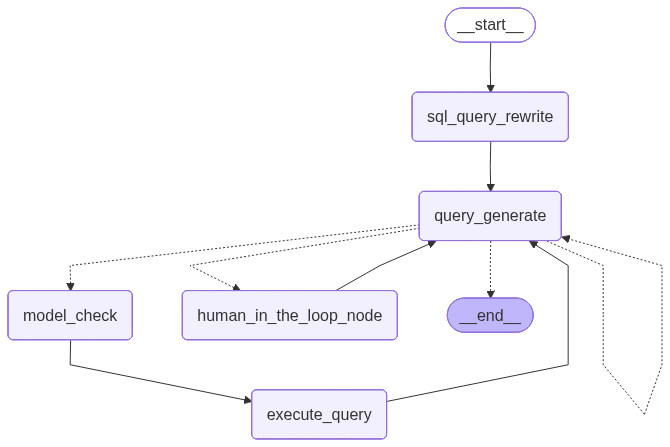

In [25]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [26]:
thread_id = '1'
config = RunnableConfig(
    recursion_limit=10, configurable={"thread_id": thread_id}
)

inputs = SqlState({
    "origin_query": HumanMessage(content="가장 최근에 올린 클린 엔 저크 영상의 분석 결과에서 상체에서 가장 낮은 점수를 조회해줘."),
    "user_id": '1',
    "error_num": 0
    })
    
for step in app.stream(inputs, config):
    if "rewritten_query" in step and step["rewritten_query"]:
        for msg in step["rewritten_query"]:
            print(f"[rewritten_query]\n{msg.content}\n\n")

    for key, val in step.items():
        if isinstance(val, dict) and "messages" in val:            
            for msg in val["messages"]:
                print(f"[{key}]\n{msg.content}\n\n")

[sql_query_rewrite]
가장 최근에 업로드된 인상 영상의 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치' 부위에서 가장 낮은 점수를 조회.


[query_generate]
SELECT 
    s.connection_name,
    ps.user_score,
    ps.status
FROM pose_scores AS ps
JOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id
JOIN sports AS sp ON ses.sport_id = sp.id
JOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index
JOIN videos AS v ON ses.user_video_id = v.id
WHERE ses.user_id = 1
AND sp.name = '인상'
AND s.connection_name IN ('왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치')
ORDER BY ps.user_score ASC
LIMIT 1;


[model_check]



[execute_query]
[{'connection_name': '오른쪽어깨-오른쪽팔꿈치', 'user_score': Decimal('82.3700'), 'status': 'warning'}]


[query_generate]
Answer: 가장 최근에 업로드된 인상 영상의 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치' 부위에서 가장 낮은 점수는 82.3700이며, 상태는 'warning'입니다.




In [110]:
# 일단 이거 잘못됨.
# 동의어 처리로 동작명에 대한 전처리 필요함.

thread_id = '2'
config = RunnableConfig(
    recursion_limit=15, configurable={"thread_id": thread_id}
)

inputs = SqlState({
    "origin_query": HumanMessage(content="snatch 영상의 분석 결과에서 골반 부위 점수의 점수 동향을 알려줘."),
    "user_id": '1',
    "error_num": 0
    })
    
for step in app.stream(inputs, config):
    if "rewritten_query" in step and step["rewritten_query"]:
        for msg in step["rewritten_query"]:
            print(f"[rewritten_query]\n{msg.content}\n\n")

    for key, val in step.items():
        if isinstance(val, dict) and "messages" in val:            
            for msg in val["messages"]:
                print(f"[{key}]\n{msg.content}\n\n")

[sql_query_rewrite]
스내치 영상의 '왼쪽엉덩이-왼쪽무릎', '오른쪽엉덩이-오른쪽무릎' 부위 점수의 동향을 조회.


[query_generate]
SELECT 
    s.connection_name,
    ps.user_score,
    ps.status
FROM pose_scores AS ps
JOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id
JOIN sports AS sp ON ses.sport_id = sp.id
JOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index
JOIN videos AS v ON ses.user_video_id = v.id
WHERE ses.user_id = 1
AND sp.name = '인상'
AND s.connection_name IN ('왼쪽엉덩이-왼쪽무릎', '오른쪽엉덩이-오른쪽무릎');


content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 141, 'prompt_tokens': 828, 'total_tokens': 969, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CddVdrv47dezZjDu

In [28]:
thread_id = '3'
config = RunnableConfig(
    recursion_limit=10, configurable={"thread_id": thread_id}
)

inputs = {
    "origin_query": HumanMessage(content="가장 최근에 올린 snatch 영상의 분석 결과에서 상체에서 가장 낮은 점수를 조회해줘."),
    "user_id": '1'
    }

# result = app.invoke(inputs, config)
for step in app.stream(inputs, config):
    if "rewritten_query" in step and step["rewritten_query"]:
        for msg in step["rewritten_query"]:
            print(f"[rewritten_query]\n{msg.content}\n\n")

    for key, val in step.items():
        if isinstance(val, dict) and "messages" in val:            
            for msg in val["messages"]:
                print(f"[{key}]\n{msg.content}\n\n")

[sql_query_rewrite]
가장 최근에 업로드된 용상 영상의 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치' 부위에서 가장 낮은 점수를 조회.


[query_generate]
SELECT 
    s.connection_name,
    ps.user_score,
    ps.status
FROM pose_scores AS ps
JOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id
JOIN sports AS sp ON ses.sport_id = sp.id
JOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index
JOIN videos AS v ON ses.user_video_id = v.id
WHERE ses.user_id = 1
AND sp.name = '용상'
AND s.connection_name IN ('왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치')
ORDER BY ps.user_score ASC
LIMIT 1;


[model_check]



[execute_query]
No Result: there is no result.


[query_generate]
SELECT 
    s.connection_name,
    ps.user_score,
    ps.status
FROM pose_scores AS ps
JOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id
JOIN sports AS sp ON ses.sport_id = sp.id
JOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index
JOIN videos AS v ON ses.user_video_id = v.id
WHERE ses.user_id = 1


GraphRecursionError: Recursion limit of 10 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT

In [ ]:
result['messages']

[AIMessage(content="가장 최근에 업로드된 용상 영상의 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치' 부위에서 가장 낮은 점수를 조회.", additional_kwargs={}, response_metadata={}, id='0bef11da-0915-4254-87c0-922e65a1d2d9'),
 AIMessage(content="SELECT \n    s.connection_name,\n    ps.user_score,\n    ps.status\nFROM pose_scores AS ps\nJOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id\nJOIN sports AS sp ON ses.sport_id = sp.id\nJOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index\nJOIN videos AS v ON ses.user_video_id = v.id\nWHERE ses.user_id = 1\nAND sp.name = '용상'\nAND s.connection_name IN ('왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치')\nORDER BY ps.user_score ASC\nLIMIT 1;", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 1194, 'total_tokens': 1345, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio

In [33]:
inputs = {
    "origin_query": HumanMessage(content="가장 최근에 올린 인상 영상의 분석 결과에서 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치'에서 가장 낮은 점수를 조회해줘."),
    "user_id": '1'
    }

for step in app.stream(inputs, config):
    if "rewritten_query" in step and step["rewritten_query"]:
        for msg in step["rewritten_query"]:
            print(f"[rewritten_query]\n{msg.content}\n\n")

    for key, val in step.items():
        if isinstance(val, dict) and "messages" in val:            
            for msg in val["messages"]:
                print(f"[{key}]\n{msg.content}\n\n")

SQL QUERY
```sql
SELECT 
    s.connection_name,
    ps.user_score,
    ps.status
FROM pose_scores AS ps
JOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id
JOIN sports AS sp ON ses.sport_id = sp.id
JOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index
JOIN videos AS v ON ses.user_video_id = v.id
WHERE ses.user_id = 1
AND sp.name = '인상'
AND s.connection_name IN ('왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치')
ORDER BY ps.user_score ASC
LIMIT 1;
```
Answer: 가장 최근에 업로드된 인상 영상의 분석 결과에서 '오른쪽어깨-오른쪽팔꿈치' 부위의 점수는 82.3700이며, 상태는 'warning'입니다.


{'origin_query': HumanMessage(content="가장 최근에 올린 인상상 영상의 분석 결과에서 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치'에서 가장 낮은 점수를 조회해줘.", additional_kwargs={}, response_metadata={}),
 'rewritten_query': [AIMessage(content="가장 최근에 업로드된 인상 영상의 분석 결과에서 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치' 부위의 가장 낮은 점수를 조회.", additional_kwargs={}, response_metadata={}, id='013e97c4-cc60-4304-afd7-3b2f45d60ffd')],
 'user_id': '1',
 'messages': [AIMessage(content="[Query Rewritten] 가장 최근에 업로드된 인상 영상의 분석 결과에서 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치' 부위의 가장 낮은 점수를 조회.", additional_kwargs={}, response_metadata={}, id='27f9d701-d76c-4e2a-94ee-2aa734e8fb58'),
  AIMessage(content="SQL QUERY\n```sql\nSELECT \n    s.connection_name,\n    ps.user_score,\n    ps.status\nFROM pose_scores AS ps\nJOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id\nJOIN sports AS sp ON ses.sport_id = sp.id\nJOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index\nJOIN videos AS v ON ses.user_video_id = v.id\n

In [52]:
# 
config = RunnableConfig(
    recursion_limit=15, configurable={"thread_id": uuid.uuid4()}
)

inputs = {
    "origin_query": HumanMessage(content="가장 최근에 올린 clean and 저크 영상의 분석 결과에서 상체에서 가장 낮은 점수를 조회해줘."),
    "user_id": '2'
}

for step in app.stream(inputs, config):
    if "rewritten_query" in step and step["rewritten_query"]:
        for msg in step["rewritten_query"]:
            print(f"[rewritten_query]\n{msg.content}\n\n")

    for key, val in step.items():
        if isinstance(val, dict) and "messages" in val:            
            for msg in val["messages"]:
                print(f"[{key}]\n{msg.content}\n\n")

[sql_query_rewrite]
[Query Rewritten] 가장 최근에 업로드된 인상 영상의 '왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치' 부위에서 가장 낮은 점수를 조회.


[query_generate]
SELECT 
    s.connection_name,
    ps.user_score,
    ps.status
FROM pose_scores AS ps
JOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id
JOIN sports AS sp ON ses.sport_id = sp.id
JOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index
JOIN videos AS v ON ses.user_video_id = v.id
WHERE ses.user_id = 2
AND sp.name = '인상'
AND s.connection_name IN ('왼쪽어깨-오른쪽어깨', '왼쪽어깨-왼쪽팔꿈치', '오른쪽어깨-오른쪽팔꿈치')
ORDER BY ps.user_score ASC
LIMIT 1;


[model_check]



[execute_query]
No Result: there is no result.


[query_generate]
SELECT 
    s.connection_name,
    ps.user_score,
    ps.status
FROM pose_scores AS ps
JOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id
JOIN sports AS sp ON ses.sport_id = sp.id
JOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index
JOIN videos AS v ON ses.user_video_id = v.id
WHER

In [ ]:
config = RunnableConfig(
    recursion_limit=10, configurable={"thread_id": uuid.uuid4()}
)

inputs = {
    "origin_query": HumanMessage(content="snatch 영상의 분석 결과에서 골반 부위 점수의 점수 동향을 알려줘."),
    "user_id": 2
    }

for step in app.stream(inputs, config):
    if "rewritten_query" in step and step["rewritten_query"]:
        for msg in step["rewritten_query"]:
            print(f"[rewritten_query]\n{msg.content}\n\n")

    for key, val in step.items():
        if isinstance(val, dict) and "messages" in val:            
            for msg in val["messages"]:
                print(f"[{key}]\n{msg.content}\n\n")

c:\Users\owner\anaconda3\envs\SportAgent\Lib\concurrent\futures\_base.py:161: RuntimeWarning: coroutine 'get_all_score_history' was never awaited
  pending_count = sum(


------query_rewrite------
용상 영상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회.
------------------------------
------db_query_tool------
[]
------------------------------
{'origin_query': HumanMessage(content='snatch 영상의 분석 결과에서 골반 부위 점수의 점수 동향을 알려줘.', additional_kwargs={}, response_metadata={}), 'rewritten_query': [AIMessage(content="용상 영상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회.", additional_kwargs={}, response_metadata={}, id='4fd70e37-005b-4718-821d-9bde2419ee99')], 'user_id': 2, 'messages': [AIMessage(content="SELECT \n    ps.user_score,\n    ps.status,\n    ses.created_at\nFROM pose_scores AS ps\nJOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id\nJOIN sports AS sp ON ses.sport_id = sp.id\nJOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index\nWHERE ses.user_id = 2\nAND sp.name = '인상'\nAND s.connection_name = '왼쪽엉덩이-오른쪽엉덩이';", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 105, 'prompt_tokens': 1099, 'total_tokens': 1204, 'comple

In [37]:
if "__interrupt__" in result:
    interrupt_data = result["__interrupt__"]
    print(interrupt_data)

[Interrupt(value={'rewritten_query': [AIMessage(content="용상 영상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회.", additional_kwargs={}, response_metadata={}, id='4fd70e37-005b-4718-821d-9bde2419ee99')], 'user_data': '<coroutine object get_all_score_history at 0x0000024244915A40>'}, id='455027b1ea9225bfede6752a388663f2')]


In [ ]:
app.invoke({"rewritten_query": "인상 용상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회"}, config)

------query_rewrite------
용상 영상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회.
------------------------------
------db_query_tool------
[]
------------------------------
------db_query_tool------
[]
------------------------------


{'origin_query': HumanMessage(content='snatch 영상의 분석 결과에서 골반 부위 점수의 점수 동향을 알려줘.', additional_kwargs={}, response_metadata={}),
 'rewritten_query': [AIMessage(content="용상 영상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회.", additional_kwargs={}, response_metadata={}, id='4fd70e37-005b-4718-821d-9bde2419ee99'),
  HumanMessage(content="인상 용상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회", additional_kwargs={}, response_metadata={}, id='c410784c-24c0-4162-8b0b-fe8b36b7d0e9'),
  AIMessage(content="용상 영상의 '왼쪽엉덩이-오른쪽엉덩이' 부위 점수 동향을 조회.", additional_kwargs={}, response_metadata={}, id='d2d71002-492f-4c1d-b5dd-1685a9bb751b')],
 'user_id': 2,
 'messages': [AIMessage(content="SELECT \n    ps.user_score,\n    ps.status,\n    ses.created_at\nFROM pose_scores AS ps\nJOIN pose_evaluation_sessions AS ses ON ps.session_id = ses.id\nJOIN sports AS sp ON ses.sport_id = sp.id\nJOIN sport_standard_scores AS s ON ps.connection_index = s.connection_index\nWHERE ses.user_id = 2\nAND sp.name = '인상'\nAND s.connection_name = '왼쪽엉덩이-오른쪽엉덩이';", addi

일단 쉽게 생각하자.
1. intent 분류 정확성 테스트하자.
2. 복합질의 중에서 실현 가능한 것, 실현 불가능한 것을 선택해서 수행할 수 있도록 하자.
    * 실현 가능한 것은 정확하게 실현 되도록
    * 실현할 수 없는 것은 hitl을 이용해서 선택하도록 하자.